In [5]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("D:/Data Analyst/project/Python_Netflix_Content_Analysis/dataset/netflix_titles.csv")

# Data Cleanup
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['rating'] = df['rating'].fillna("Unknown")

In [6]:
# Extract Month Column
df['month_added'] = df['date_added'].dt.month.astype('Int64')

In [7]:
df_plot = df['month_added'].value_counts().reset_index()
df_plot = df_plot.sort_values(by='month_added')
df_plot['Month_Name'] = df_plot['month_added'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_plot = df_plot.set_index('Month_Name')
df_plot = df_plot.drop(columns='month_added')

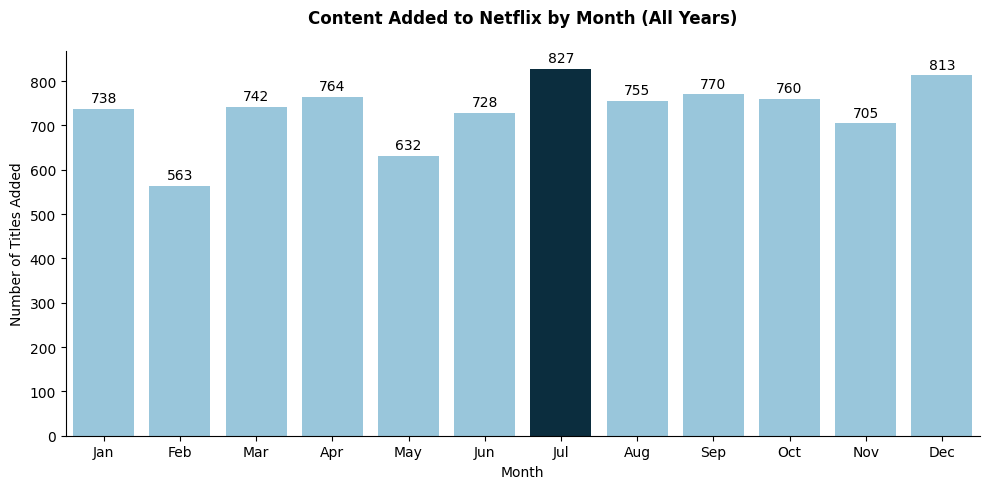

In [8]:
plt.figure(figsize=(10, 5))

colors = [
    '#023047' if value == df_plot['count'].max() else '#8ECAE6'
    for value in df_plot['count'] 
]

sns.barplot(
    data=df_plot, 
    x='Month_Name', 
    y='count',
    hue='Month_Name', 
    palette=colors,
    legend=False
)
sns.despine()

plt.title('Content Added to Netflix by Month (All Years)', fontweight='bold', pad=20)
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')

for i, value in enumerate(df_plot['count']):
    plt.text(i, value + 15, str(value), ha='center')

plt.tight_layout()
plt.show()